# Third degree Markov model for generating music
Database: [hansespinosa2 - 30000 Video Game MIDI Files](www.kaggle.com/datasets/hansespinosa2/40000-video-game-midi-files/data)

## Imports and constants

In [55]:
## Imports

from collections import Counter, defaultdict
from pathlib import Path
import json
import random
import pygame
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import seaborn as sns
from IPython.display import display
import threading
import time

## Constants

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

DATA_DIR = Path("data/hansespinosa2/40000-video-game-midi-files/versions/2")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
MAX_FILES = 250
MIN_NOTES_PER_FILE = 12
DURATION_GRID = 0.25
RHYTHM_GRID = 0.25
RARE_STATE_THRESHOLD = 2
LAPLACE_ALPHA = 0.05
TEMPERATURE = 0.9
MARKOV_ORDER = 3

print(f"Data: {DATA_DIR.resolve()}\nOutput: {OUTPUT_DIR.resolve()}")

Data: D:\Programiranje\etf_projekti\asm-projekat-x\data\hansespinosa2\40000-video-game-midi-files\versions\2
Output: D:\Programiranje\etf_projekti\asm-projekat-x\output


## Metadata creation

In [7]:
def midi_metadata(path):
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        return {
            "path": str(path),
            "duration_s": midi.get_end_time(),
            "tracks": len(midi.instruments),
            "instruments": [instr.name for instr in midi.instruments],
            "tempo_bpm": float(np.median(midi.get_tempo_changes()[1])) if len(midi.get_tempo_changes()[1]) else np.nan,
            "valid": True,
        }
    except Exception as error:
        return {"path": str(path), "duration_s": np.nan, "tracks": 0, "instruments": [], "tempo_bpm": np.nan, "valid": False, "error": str(error)}

In [9]:
midi_paths = sorted(
    path for path in DATA_DIR.rglob("*")
    if path.suffix.lower() in {".mid", ".midi"}
)
assert midi_paths, "No MIDI files found."
selected_paths = list(rng.choice(midi_paths, size=min(MAX_FILES, len(midi_paths)), replace=False))

metadata = pd.DataFrame(midi_metadata(path) for path in selected_paths)
valid_paths = [Path(path) for path in metadata.loc[metadata.valid, "path"]]
print(f"Found: {len(midi_paths)} | Sample: {len(selected_paths)} | Valid: {len(valid_paths)}")
display(metadata[metadata.valid].describe(include="all"))

c:\Users\Danilo\miniforge3\envs\faks_311\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Found: 12584 | Sample: 250 | Valid: 248


,path,duration_s,tracks,instruments,tempo_bpm,valid,error
count,248,248.000000,248.000000,248,248.000000,248,0
unique,248,NaN,NaN,209,NaN,1,0
top,data\hansespinosa2\40000-video-game-midi-files...,NaN,NaN,"[Right Hand, Left Hand]",NaN,True,NaN
freq,1,NaN,NaN,8,NaN,248,NaN
mean,NaN,98.119318,7.564516,NaN,131.853801,NaN,NaN
std,NaN,82.685841,5.281918,NaN,41.258737,NaN,NaN
min,NaN,0.818181,1.000000,NaN,35.000015,NaN,NaN
25%,NaN,43.752378,4.000000,NaN,108.999944,NaN,NaN
50%,NaN,82.294359,6.000000,NaN,120.000000,NaN,NaN
75%,NaN,131.814538,10.000000,NaN,150.000000,NaN,NaN


In [10]:
display(metadata[metadata.valid][["path", "duration_s", "tracks", "tempo_bpm", "instruments"]])

,path,duration_s,tracks,tempo_bpm,instruments
0,data\hansespinosa2\40000-video-game-midi-files...,136.615248,7,130.000130,"[choroE, choroD, fagote, marimba, tímbales, fl..."
1,data\hansespinosa2\40000-video-game-midi-files...,61.440000,5,125.000000,"[Track 1, Track 2, Track 3, Track 5, Track 4]"
2,data\hansespinosa2\40000-video-game-midi-files...,174.545600,6,109.999908,"[Piano Treble, Piano Bass, Flute, Bass, String..."
3,data\hansespinosa2\40000-video-game-midi-files...,192.000000,8,160.000000,"[Staff-4, Staff-5, Staff-6, Staff, Staff-3, St..."
4,data\hansespinosa2\40000-video-game-midi-files...,57.187500,4,128.000000,"[Flume, Flume, Flume, Flume]"
...,...,...,...,...,...
245,data\hansespinosa2\40000-video-game-midi-files...,11.454534,10,220.000220,"[tk1, tk2, tk3, tk4, tk5, tk6, tk7, tk8, tk9, ..."
246,data\hansespinosa2\40000-video-game-midi-files...,110.996875,6,120.000000,"[Piano, Piano 2, Trumpet, Strings, Sequenced B..."
247,data\hansespinosa2\40000-video-game-midi-files...,273.600000,8,125.000000,"[Cloud Cuckooland Remix, Cloud Cuckooland Remi..."
248,data\hansespinosa2\40000-video-game-midi-files...,75.502706,11,79.510032,[DK64 -- Cranky's Lab (Halloween Remix) -- by ...


## Preprocessing

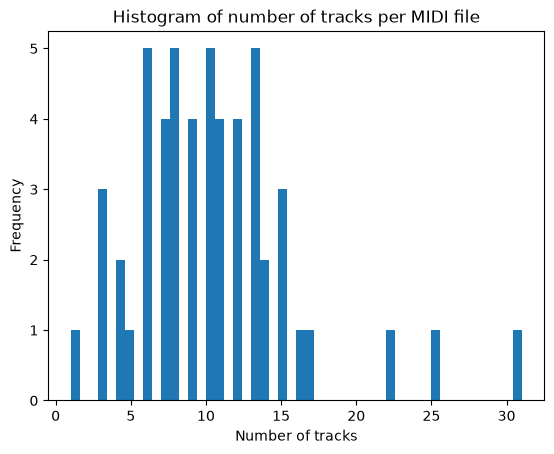

In [16]:
plt.hist(metadata_with_bass.loc[metadata.valid, "tracks"], bins=50)
plt.xlabel("Number of tracks")
plt.ylabel("Frequency")
plt.title("Histogram of number of tracks per MIDI file")
plt.show()

c:\Users\Danilo\miniforge3\envs\faks_311\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


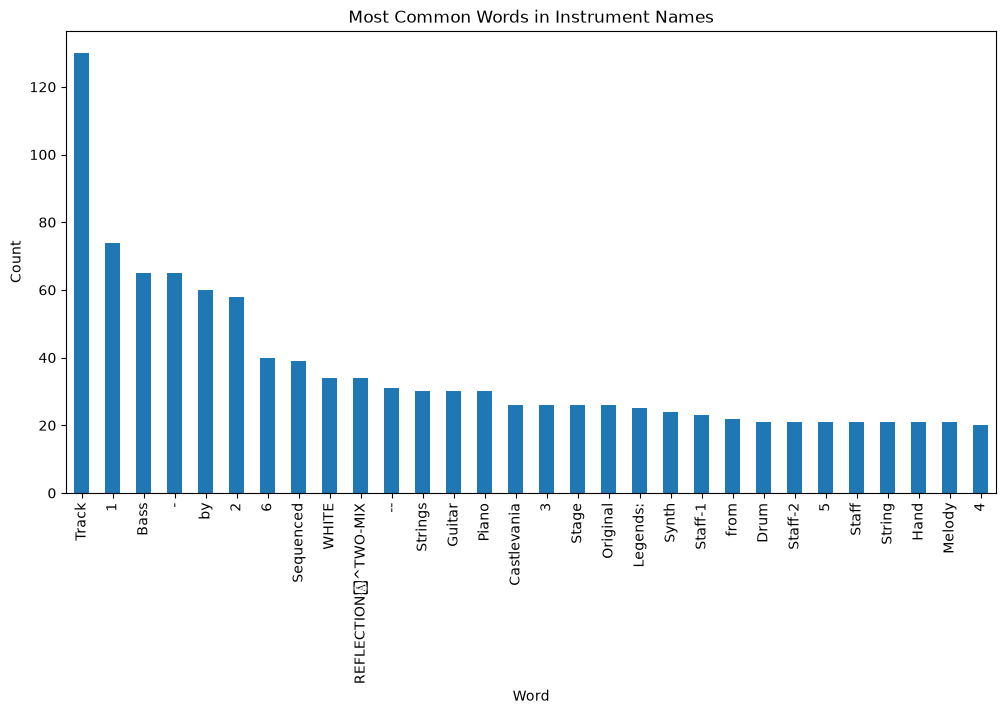

In [11]:
all_instruments = []
for midi in metadata[metadata.valid]["instruments"]:
    for instr in midi:
        all_instruments.extend(instr.split())

unique_instruments = pd.DataFrame({"instrument": all_instruments})
unique_instruments = unique_instruments[unique_instruments["instrument"].map(unique_instruments["instrument"].value_counts()) >= 20]
unique_instruments["instrument"].value_counts().plot(kind="bar", figsize=(12, 6))
plt.title("Most Common Words in Instrument Names")
plt.xlabel("Word")
plt.ylabel("Count")
plt.show()

#### We will create a Markov model to generate bass lines for video game soundtracks

In [18]:
# keep only the midi files that have the word bass in their instrument names lowercase or uppercase doesn't matter
metadata = metadata[metadata.valid].copy()
metadata = metadata[metadata["instruments"].apply(lambda midi: any("bass" in instr.lower() for instr in midi))]
print('Amount of MIDI files with bass:', len(metadata))

Amount of MIDI files with bass: 53


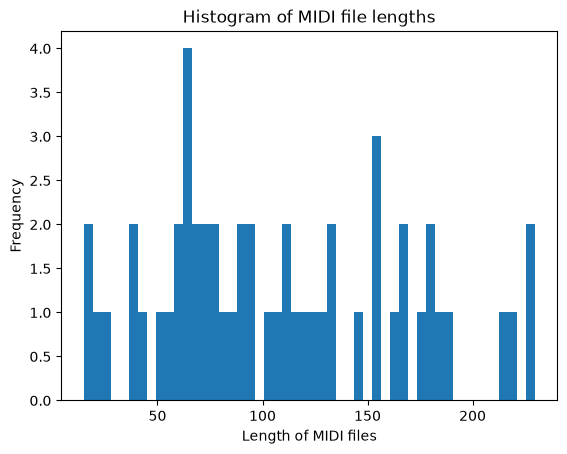

In [19]:
plt.hist(metadata.loc[metadata.valid, "duration_s"], bins=50)
plt.xlabel("Length of MIDI files")
plt.ylabel("Frequency")
plt.title("Histogram of MIDI file lengths")
plt.show()

In [22]:
metadata = metadata.loc[metadata["duration_s"] <= 200]
valid_paths = [Path(path) for path in metadata["path"]]
print('Amount of valid MIDI files with duration <= 200s:', len(valid_paths))

Amount of valid MIDI files with duration <= 200s: 49


## Parsing MIDI files into an event sequence

In [26]:
def dominant_notes(path):
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        instruments = [instrument for instrument in midi.instruments if not instrument.is_drum and instrument.notes and "bass" in instrument.name.lower()]
        if not instruments:
            return []
        notes = sorted(max(instruments, key=lambda instrument: len(instrument.notes)).notes, key=lambda note: (note.start, -note.pitch))
        melody = []
        for note in notes:
            if not melody or note.start >= melody[-1].end - 1e-4:
                melody.append(note)
            elif note.pitch > melody[-1].pitch:
                melody[-1] = note
        return melody
    except Exception:
        return []

In [27]:
raw_sequences = [(path, dominant_melody_notes(path)) for path in valid_paths]
raw_sequences = [(path, notes) for path, notes in raw_sequences if len(notes) >= MIN_NOTES_PER_FILE]
print(f"Sequences with at least {MIN_NOTES_PER_FILE} notes: {len(raw_sequences)}")

Sequences with at least 12 notes: 47


## Extraction of characteristics

In [29]:
PITCH_CLASSES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

def quantize(value, grid):
    return max(grid, round(value / grid) * grid)

def notes_to_events(notes):
    events = []
    for index, note in enumerate(notes):
        next_start = notes[index + 1].start if index + 1 < len(notes) else note.end
        events.append({
            "pitch": int(note.pitch),
            "duration": quantize(note.end - note.start, DURATION_GRID),
            "onset_gap": quantize(max(0, next_start - note.start), RHYTHM_GRID),
            "chord": PITCH_CLASSES[note.pitch % 12],
        })
    return events

In [30]:
event_sequences = [(path, notes_to_events(notes)) for path, notes in raw_sequences]
print("Event sequence sample:", event_sequences[0][1][:4])

Event sequence sample: [{'pitch': 53, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'F'}, {'pitch': 57, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'A'}, {'pitch': 60, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'C'}, {'pitch': 65, 'duration': 0.25, 'onset_gap': 0.25, 'chord': 'F'}]


## State discretization and tokenization

In [32]:
UNK = ("UNK", "UNK", "UNK", "UNK")

def event_token(event):
    return (event["pitch"], event["duration"], event["onset_gap"], event["chord"])

def encode_sequence(sequence):
    return [token if token_counts[token] >= RARE_STATE_THRESHOLD else UNK for token in map(event_token, sequence)]

In [33]:
all_tokens = [event_token(event) for _, sequence in event_sequences for event in sequence]
token_counts = Counter(all_tokens)

encoded_sequences = [encode_sequence(sequence) for _, sequence in event_sequences]
states = sorted(set(token for sequence in encoded_sequences for token in sequence), key=str)
state_to_index = {state: index for index, state in enumerate(states)}
index_to_state = {index: state for state, index in state_to_index.items()}
encoded_indices = [[state_to_index[token] for token in sequence] for sequence in encoded_sequences]
print(f"Number of states: {len(states)} | Number of tokens: {len(all_tokens)}")

Number of states: 234 | Number of tokens: 17253


## Training

In [35]:
def build_ngram_counts(sequences, order):
    counts = defaultdict(Counter)
    for sequence in sequences:
        for index in range(len(sequence) - order):
            context = tuple(sequence[index:index + order])
            next_state = sequence[index + order]
            counts[context][next_state] += 1
    return counts

def train_markov(sequences, n_states, order=MARKOV_ORDER, alpha=LAPLACE_ALPHA):
    unigram = np.full(n_states, alpha, dtype=float)
    for sequence in sequences:
        for state in sequence:
            unigram[state] += 1
    unigram /= unigram.sum()

    order_counts = {level: build_ngram_counts(sequences, level) for level in range(1, order + 1)}
    initial_contexts = Counter(tuple(sequence[:order]) for sequence in sequences if len(sequence) >= order)
    return unigram, order_counts, initial_contexts

def serialize_counts(counts):
    return {"|".join(map(str, context)): dict(counter) for context, counter in counts.items()}


In [37]:
unigram_probs, transition_counts, initial_contexts = train_markov(encoded_indices, len(states))
assert np.allclose(unigram_probs.sum(), 1)

model_payload = {
    "order": MARKOV_ORDER,
    "alpha": LAPLACE_ALPHA,
    "unigram": unigram_probs.tolist(),
    "transition_counts": {level: serialize_counts(counts) for level, counts in transition_counts.items()},
    "initial_contexts": {"|".join(map(str, context)): count for context, count in initial_contexts.items()},
}
with open(OUTPUT_DIR / "markov_model.json", "w", encoding="utf-8") as output_file:
    json.dump(model_payload, output_file, ensure_ascii=False)
with open(OUTPUT_DIR / "states.json", "w", encoding="utf-8") as output_file:
    json.dump([list(state) for state in states], output_file, ensure_ascii=False)
print(f"Model saved. Number of contexts per order:", {level: len(counts) for level, counts in transition_counts.items()})

Model saved. Number of contexts per order: {1: 234, 2: 1243, 3: 2297}


## Bass line generation

In [38]:
def tempered(probabilities, temperature=TEMPERATURE):
    logits = np.log(np.clip(probabilities, 1e-12, None)) / temperature
    weights = np.exp(logits - logits.max())
    return weights / weights.sum()

def context_distribution(context, order, temperature):
    """Vraca (stanja, verovatnoce) za dati kontekst, uz backoff na krace kontekste i unigram."""
    for level in range(order, 0, -1):
        sub_context = context[-level:]
        counts = transition_counts[level].get(sub_context)
        if counts:
            next_states = np.array(list(counts.keys()))
            counts_arr = np.full(len(next_states), LAPLACE_ALPHA, dtype=float) + np.array(list(counts.values()), dtype=float)
            return next_states, tempered(counts_arr / counts_arr.sum(), temperature)
    all_states = np.arange(len(unigram_probs))
    return all_states, tempered(unigram_probs, temperature)

def sample_initial_context(order, temperature):
    contexts = list(initial_contexts.keys())
    weights = np.array(list(initial_contexts.values()), dtype=float)
    weights = tempered(weights / weights.sum(), temperature)
    chosen = contexts[rng.choice(len(contexts), p=weights)]
    return list(chosen)

def generate_indices(length=80, temperature=TEMPERATURE, order=MARKOV_ORDER):
    generated = sample_initial_context(order, temperature)
    for _ in range(length - len(generated)):
        context = tuple(generated[-order:])
        next_states, probabilities = context_distribution(context, order, temperature)
        generated.append(int(rng.choice(next_states, p=probabilities)))
    return generated[:length]

def decode_indices(indices):
    fallback = next(state for state in states if state != UNK)
    return [index_to_state[index] if index_to_state[index] != UNK else fallback for index in indices]


In [39]:
generated_indices = generate_indices(length=96)
generated_tokens = decode_indices(generated_indices)
print("First ten generated states:", generated_tokens[:10])

First ten generated states: [(41, 0.25, 0.25, 'F'), (53, 0.25, 0.25, 'F'), (41, 0.25, 0.25, 'F'), (41, 0.25, 0.25, 'F'), (53, 0.25, 0.25, 'F'), (41, 0.25, 0.25, 'F'), (53, 0.25, 0.25, 'F'), (41, 0.25, 0.25, 'F'), (41, 0.25, 0.25, 'F'), (53, 0.25, 0.25, 'F')]


## Postprocessing and MIDI translation

In [40]:
def tokens_to_midi(tokens, tempo=120):
    result = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=pretty_midi.instrument_name_to_program("Acoustic Grand Piano"))
    onset = 0.0
    for pitch, duration, onset_gap, _ in tokens:
        pitch = int(np.clip(pitch, 36, 96))
        duration = max(float(duration), DURATION_GRID)
        gap = max(float(onset_gap), RHYTHM_GRID)
        instrument.notes.append(pretty_midi.Note(velocity=88, pitch=pitch, start=onset, end=onset + duration))
        onset += gap
    result.instruments.append(instrument)
    return result

TEMPERATURES = [0.5, 0.5, 0.7, 0.7, 0.9, 0.9, 1, 1, 1.15, 1.15, 1.5, 1.5]

In [41]:
generated_collections = [decode_indices(generate_indices(96, temperature)) for temperature in TEMPERATURES]
for index, tokens in enumerate(generated_collections, start=1):
    tokens_to_midi(tokens).write(str(OUTPUT_DIR / f"generated_T{TEMPERATURES[index-1]}_{index}.mid"))

preview = tokens_to_midi(generated_collections[1])
print("Saved MIDI examples:", list(OUTPUT_DIR.glob("generated_*.mid")))

Saved MIDI examples: [WindowsPath('output/generated_T0.5_1.mid'), WindowsPath('output/generated_T0.5_2.mid'), WindowsPath('output/generated_T0.7_3.mid'), WindowsPath('output/generated_T0.7_4.mid'), WindowsPath('output/generated_T0.9_5.mid'), WindowsPath('output/generated_T0.9_6.mid'), WindowsPath('output/generated_T1.15_10.mid'), WindowsPath('output/generated_T1.15_9.mid'), WindowsPath('output/generated_T1.5_11.mid'), WindowsPath('output/generated_T1.5_12.mid'), WindowsPath('output/generated_T1_7.mid'), WindowsPath('output/generated_T1_8.mid')]


## Model evaluation

In [42]:
def feature_values(sequences):
    events = [event for sequence in sequences for event in sequence]
    pitches = [event["pitch"] for event in events]
    intervals = [second - first for sequence in sequences for first, second in zip([event["pitch"] for event in sequence], [event["pitch"] for event in sequence][1:])]
    durations = [event["duration"] for event in events]
    chords = [event["chord"] for event in events]
    return {"pitch": pitches, "interval": intervals, "duration": durations, "chord": chords}

def entropy(values):
    probabilities = np.array(list(Counter(values).values()), dtype=float)
    probabilities /= probabilities.sum()
    return float(-(probabilities * np.log2(probabilities)).sum())

def ngrams(values, n=3):
    return set(tuple(values[index:index+n]) for index in range(len(values) - n + 1))

def jaccard(first, second):
    return len(first & second) / len(first | second) if first | second else np.nan

def tokens_to_events(tokens):
    return [{"pitch": int(pitch), "duration": float(duration), "onset_gap": float(gap), "chord": chord} for pitch, duration, gap, chord in tokens]

In [44]:
original_features = feature_values([sequence for _, sequence in event_sequences])
generated_event_sequences = [tokens_to_events(tokens) for tokens in generated_collections]
generated_features = feature_values(generated_event_sequences)
metrics = pd.DataFrame([
    {"group": "original", "pitch_entropy": entropy(original_features["pitch"]), "interval_entropy": entropy(original_features["interval"]), "duration_entropy": entropy(original_features["duration"]), "3-gram_Jaccard": 1.0},
    {"group": "generated", "pitch_entropy": entropy(generated_features["pitch"]), "interval_entropy": entropy(generated_features["interval"]), "duration_entropy": entropy(generated_features["duration"]), "3-gram_Jaccard": jaccard(ngrams(original_features["pitch"]), ngrams(generated_features["pitch"]))},
])
display(metrics.round(3))

,group,pitch_entropy,interval_entropy,duration_entropy,3-gram_Jaccard
0,original,5.117,3.389,0.364,1.000
1,generated,4.634,3.315,0.829,0.188


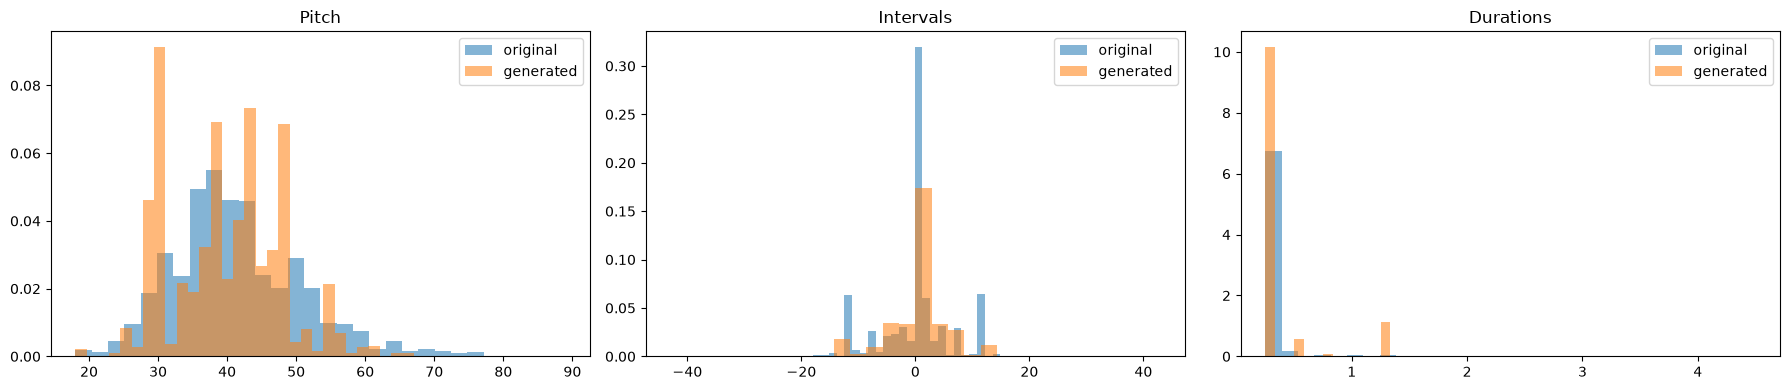

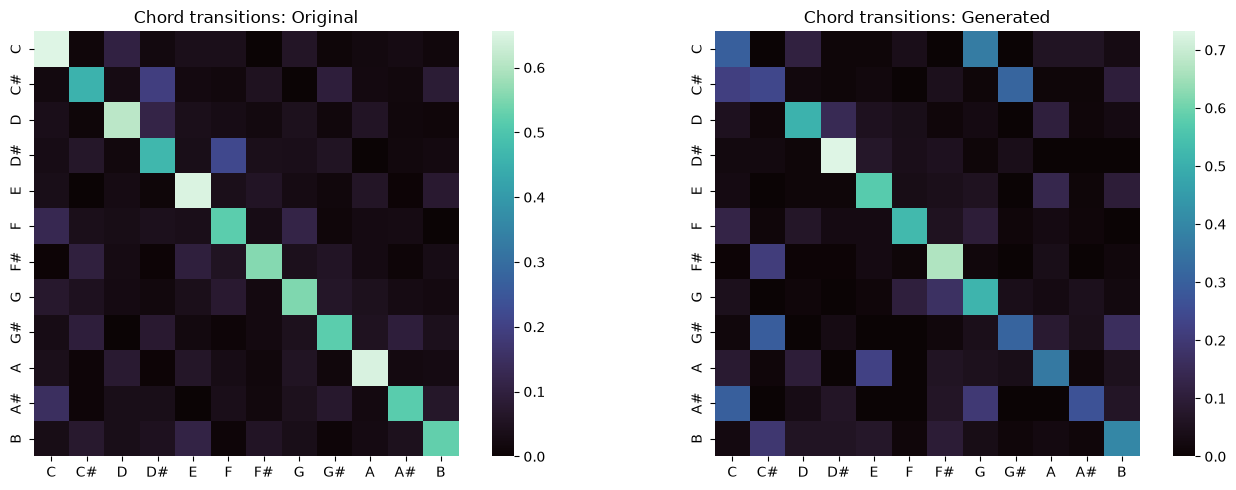

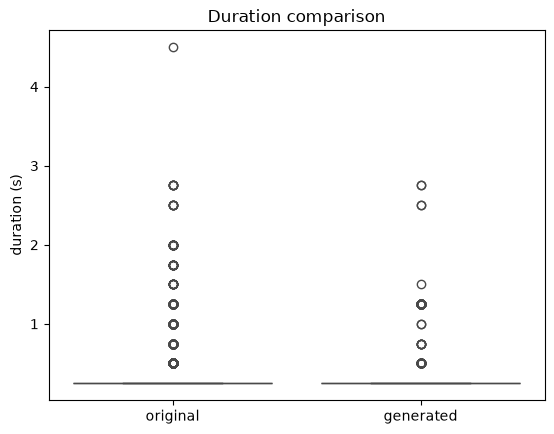

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for axis, feature, title in zip(axes, ["pitch", "interval", "duration"], ["Pitch", "Intervals", "Durations"]):
    axis.hist(original_features[feature], bins=30, density=True, alpha=0.55, label="original")
    axis.hist(generated_features[feature], bins=30, density=True, alpha=0.55, label="generated")
    axis.set_title(title)
    axis.legend()
plt.tight_layout()
plt.show()

def chord_transition_matrix(chords):
    matrix = pd.DataFrame(0, index=PITCH_CLASSES, columns=PITCH_CLASSES, dtype=float)
    for current_chord, next_chord in zip(chords, chords[1:]):
        matrix.loc[current_chord, next_chord] += 1
    return matrix.div(matrix.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, chords, title in zip(axes, [original_features["chord"], generated_features["chord"]], ["Original", "Generated"]):
    sns.heatmap(chord_transition_matrix(chords), cmap="mako", ax=axis, square=True)
    axis.set_title(f"Chord transitions: {title}")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "original": pd.Series(original_features["duration"]),
    "generated": pd.Series(generated_features["duration"]),
})
sns.boxplot(data=comparison, palette=["#4C78A8", "#F58518"], order=["original", "generated"])
plt.title("Duration comparison")
plt.ylabel("duration (s)")
plt.show()

## Listening section

In [54]:
def play_music(music_file):
    clock = pygame.time.Clock()
    try:
        pygame.mixer.music.load(music_file)
        print("Music file %s loaded!" % music_file)
    except pygame.error:
        print("File %s not found! (%s)" % (music_file, pygame.get_error()))
        return
    pygame.mixer.music.play()
    while pygame.mixer.music.get_busy():
        clock.tick(30)

def play_for_10_seconds(midi_file):
    thread = threading.Thread(target=play_music, args=(midi_file,))
    thread.start()
    time.sleep(10)
    pygame.mixer.music.stop()
    thread.join()

freq = 44100
bitsize = -16
channels = 2
buffer = 1024
pygame.mixer.init(freq, bitsize, channels, buffer)
pygame.mixer.music.set_volume(0.8)

In [56]:
print("Example of the dataset midi file")
midi_file = metadata.loc[metadata.valid, "path"].iloc[10]
example_midi = pretty_midi.PrettyMIDI(str(midi_file))
example_midi.instruments = [instrument for instrument in example_midi.instruments if not instrument.is_drum and instrument.notes and "bass" in instrument.name.lower()]
example_midi.write(str('example.mid'))
play_for_10_seconds('example.mid')

Example of the dataset midi file
Music file example.mid loaded!


In [59]:
print("Example of the generated midi file with temperature 0.5")
generated_midi_file = "output/generated_T0.5_2.mid"
midi = pretty_midi.PrettyMIDI(str(generated_midi_file))
for instrument in midi.instruments:
    instrument.name = example_midi.instruments[0].name
    instrument.program = example_midi.instruments[0].program
midi.write(str(generated_midi_file))
play_for_10_seconds(generated_midi_file)

Example of the generated midi file with temperature 0.5
Music file output/generated_T0.5_2.mid loaded!


In [60]:
print("Example of the generated midi file with temperature 1")
generated_midi_file = "output/generated_T1_7.mid"
midi = pretty_midi.PrettyMIDI(str(generated_midi_file))
for instrument in midi.instruments:
    instrument.name = example_midi.instruments[0].name
    instrument.program = example_midi.instruments[0].program
midi.write(str(generated_midi_file))
play_for_10_seconds(generated_midi_file)

Example of the generated midi file with temperature 1
Music file output/generated_T1_7.mid loaded!


In [61]:
print("Example of the generated midi file with temperature 1.5")
generated_midi_file = "output/generated_T1.5_12.mid"
midi = pretty_midi.PrettyMIDI(str(generated_midi_file))
for instrument in midi.instruments:
    instrument.name = example_midi.instruments[0].name
    instrument.program = example_midi.instruments[0].program
midi.write(str(generated_midi_file))
play_for_10_seconds(generated_midi_file)

Example of the generated midi file with temperature 1.5
Music file output/generated_T1.5_12.mid loaded!
